<a href="https://colab.research.google.com/github/AFANDI-ie/AFANDI-ie.github.io/blob/main/UTS_DATA_MINING_FARIZ_AFANDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. PERSIAPAN DATA**

In [1]:
# Install library yang dibutuhkan
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (RandomForestClassifier,
                               ExtraTreesClassifier,
                               GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✓ Semua library berhasil diimport")

✓ Semua library berhasil diimport


In [3]:
# Load dataset training dan testing
train = pd.read_csv("data_training.csv")
test  = pd.read_csv("data_testing.csv")

print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah data training : {train.shape[0]} baris, {train.shape[1]} kolom")
print(f"Jumlah data testing  : {test.shape[0]} baris, {test.shape[1]} kolom")
print()
print("Kolom data training:", list(train.columns))
print("Kolom data testing :", list(test.columns))
print()
print("5 baris pertama data training:")
display(train.head())
print()
print("5 baris pertama data testing:")
display(test.head())

INFORMASI DATASET
Jumlah data training : 857 baris, 13 kolom
Jumlah data testing  : 286 baris, 12 kolom

Kolom data training: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']
Kolom data testing : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']

5 baris pertama data training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



5 baris pertama data testing:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Dataset training memiliki 857 baris dan 13 kolom termasuk kolom target quality. Dataset testing memiliki 286 baris dan 12 kolom (tanpa quality). Dataset ini merupakan dataset Wine Quality Red Wine dengan 11 fitur kimiawi sebagai variabel prediktor

**2. PEMBERSIHAN DATA**

In [4]:
print("=" * 50)
print("CEK MISSING VALUES")
print("=" * 50)

print("\n[Training Data]")
missing_train = train.isnull().sum()
print(missing_train)
print(f"\nTotal missing values (training): {missing_train.sum()}")

print("\n[Testing Data]")
missing_test = test.isnull().sum()
print(missing_test)
print(f"\nTotal missing values (testing): {missing_test.sum()}")

if missing_train.sum() == 0 and missing_test.sum() == 0:
    print("\n✓ Tidak ada missing values pada kedua dataset.")
    print("  Tidak diperlukan imputasi atau penghapusan data.")
else:
    print("\n⚠ Terdapat missing values, perlu dilakukan penanganan!")

CEK MISSING VALUES

[Training Data]
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values (training): 0

[Testing Data]
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

Total missing values (testing): 0

✓ Tidak ada missing values pada kedua dataset.
  Tidak diperlukan imputasi atau penghapusan data.


 Hasil pengecekan menunjukkan tidak ada nilai yang hilang (missing values) pada kedua dataset. Oleh karena itu, tidak diperlukan proses imputasi maupun penghapusan data. Dataset sudah bersih dan siap digunakan.

In [5]:
print("=" * 50)
print("STATISTIK DESKRIPTIF - TRAINING DATA")
print("=" * 50)
display(train.describe())

print("\nTipe data setiap kolom:")
print(train.dtypes)

STATISTIK DESKRIPTIF - TRAINING DATA


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000



Tipe data setiap kolom:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


Dari statistik deskriptif terlihat bahwa setiap fitur memiliki rentang nilai yang sangat berbeda-beda. Misalnya, free sulfur dioxide berkisar 1–72 sedangkan alcohol berkisar 8–14. Perbedaan skala yang besar ini membuat feature scaling menjadi wajib dilakukan agar model tidak bias terhadap fitur dengan nilai besar.

DISTRIBUSI KELAS TARGET (quality)
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Nilai unik quality: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


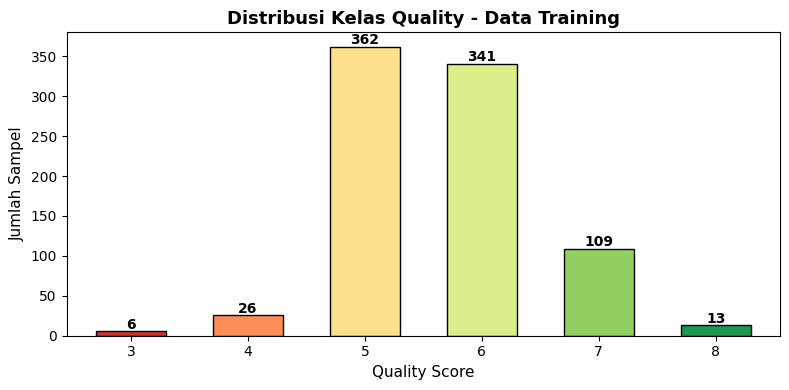

In [6]:
print("=" * 50)
print("DISTRIBUSI KELAS TARGET (quality)")
print("=" * 50)
print(train['quality'].value_counts().sort_index())
print(f"\nNilai unik quality: {sorted(train['quality'].unique())}")

plt.figure(figsize=(8, 4))
colors = ['#d73027','#fc8d59','#fee08b','#d9ef8b','#91cf60','#1a9850']
train['quality'].value_counts().sort_index().plot(
    kind='bar', color=colors, edgecolor='black', width=0.6)
plt.title('Distribusi Kelas Quality - Data Training', fontsize=13, fontweight='bold')
plt.xlabel('Quality Score', fontsize=11)
plt.ylabel('Jumlah Sampel', fontsize=11)
plt.xticks(rotation=0)
for i, v in enumerate(train['quality'].value_counts().sort_index()):
    plt.text(i, v + 3, str(v), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Distribusi kelas target sangat tidak seimbang (imbalanced). Kelas quality 5 dan 6 mendominasi dataset dengan jumlah 362 dan 341 sampel, sementara kelas 3 hanya memiliki 6 sampel dan kelas 8 hanya 13 sampel. Ketidakseimbangan ini menjadi pertimbangan penting dalam pemilihan model, yaitu menggunakan parameter class_weight='balanced' agar model tidak bias ke kelas mayoritas.

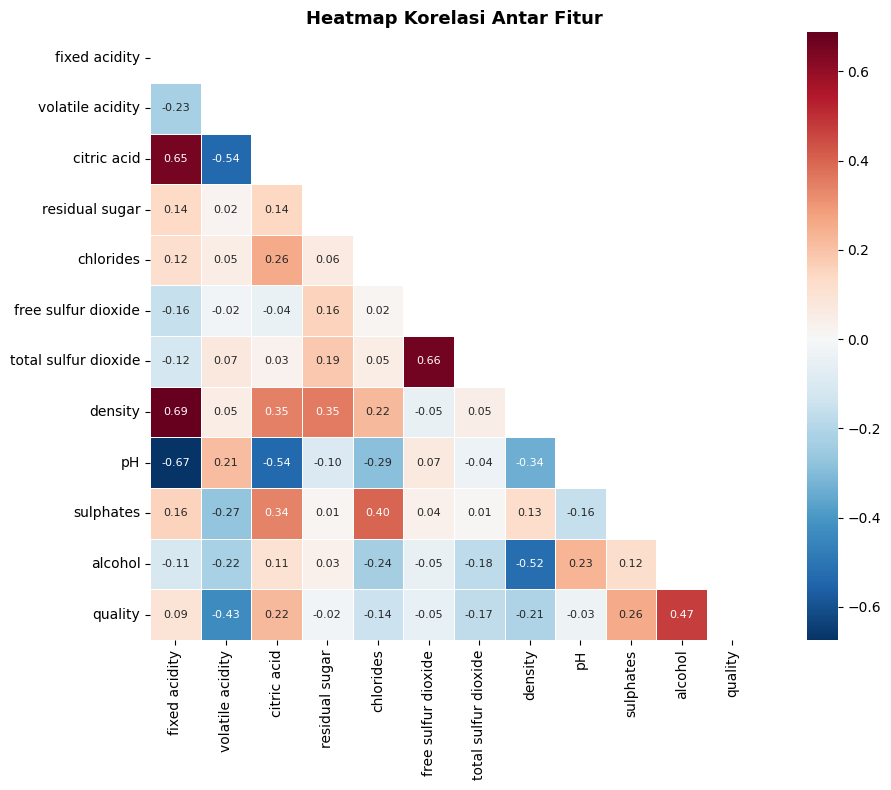

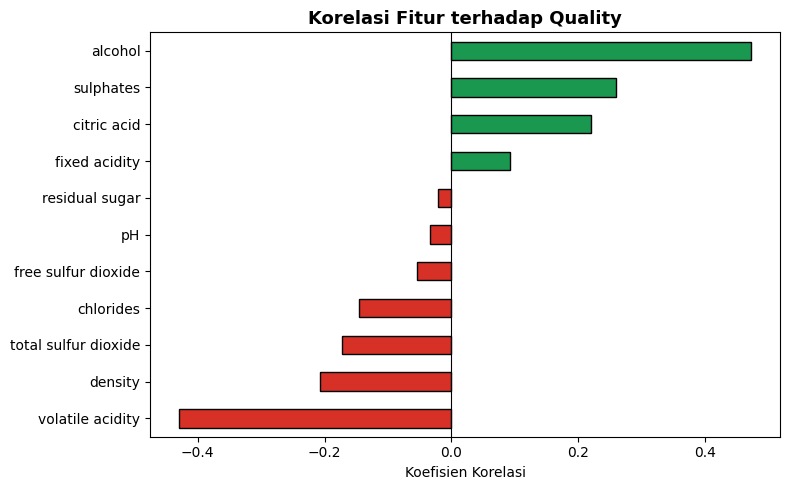

Korelasi fitur terhadap quality (diurutkan):
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


In [7]:
feature_cols = ['fixed acidity','volatile acidity','citric acid',
                'residual sugar','chlorides','free sulfur dioxide',
                'total sulfur dioxide','density','pH','sulphates','alcohol']

# Heatmap korelasi
plt.figure(figsize=(11, 8))
corr_matrix = train[feature_cols + ['quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True, mask=mask,
            annot_kws={"size": 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi fitur vs quality
corr_quality = corr_matrix['quality'].drop('quality').sort_values()
colors_bar = ['#d73027' if v < 0 else '#1a9850' for v in corr_quality]

plt.figure(figsize=(8, 5))
corr_quality.plot(kind='barh', color=colors_bar, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur terhadap Quality', fontsize=13, fontweight='bold')
plt.xlabel('Koefisien Korelasi')
plt.tight_layout()
plt.show()

print("Korelasi fitur terhadap quality (diurutkan):")
print(corr_quality.sort_values(ascending=False))

Fitur alcohol memiliki korelasi positif tertinggi dengan quality (r = 0.47), artinya semakin tinggi kadar alkohol cenderung menghasilkan kualitas anggur yang lebih baik. Sebaliknya, volatile acidity memiliki korelasi negatif terkuat (r = -0.43), yang berarti kadar volatile acidity yang tinggi cenderung menurunkan kualitas anggur. Fitur residual sugar dan pH memiliki korelasi yang sangat rendah, namun tetap dipertahankan karena model ensemble dapat menangkap hubungan non-linear.

In [8]:
# Pisahkan fitur dan target
X_train = train[feature_cols]
y_train = train['quality']
X_test  = test[feature_cols]

# Normalisasi dengan StandardScaler
# StandardScaler mengubah data sehingga mean=0 dan std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # hanya transform, TIDAK fit ulang

# Simpan scaler untuk deployment
joblib.dump(scaler, 'scaler.pkl')

print("Sebelum scaling - statistik X_train:")
print(pd.DataFrame(X_train).describe().loc[['mean','std']].round(3))
print()
print("Sesudah scaling - statistik X_train_scaled:")
print(pd.DataFrame(X_train_scaled, columns=feature_cols).describe().loc[['mean','std']].round(3))
print()
print(f"✓ Feature scaling selesai. Shape: {X_train_scaled.shape}")

Sebelum scaling - statistik X_train:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean          8.262             0.529        0.267           2.506      0.087   
std           1.702             0.179        0.195           1.294      0.049   

      free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  \
mean               15.783                45.978    0.997  3.313      0.657   
std                10.300                31.692    0.002  0.152      0.167   

      alcohol  
mean   10.430  
std     1.067  

Sesudah scaling - statistik X_train_scaled:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean          0.000            -0.000        0.000          -0.000      0.000   
std           1.001             1.001        1.001           1.001      1.001   

      free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  \
mean                0.000                -0.000    0.000  0.000     -

StandardScaler diterapkan untuk menormalisasi semua fitur sehingga memiliki mean = 0 dan standar deviasi = 1. Penting untuk dicatat bahwa fit_transform hanya dilakukan pada data training, sedangkan data testing hanya di-transform menggunakan parameter dari training. Hal ini untuk mencegah data leakage (kebocoran informasi dari testing ke training). Scaler disimpan dengan joblib untuk keperluan deployment model.

**3. PEMBUATAN MODEL**

In [9]:
print("=" * 50)
print("PEMBUATAN MODEL KLASIFIKASI")
print("=" * 50)
print("""
Model yang digunakan: Voting Ensemble (Soft Voting)
Terdiri dari 3 base model:
  1. Random Forest Classifier
  2. Extra Trees Classifier
  3. Gradient Boosting Classifier

Alasan pemilihan:
- Ensemble method lebih robust dan akurat dibanding single model
- class_weight='balanced' untuk menangani imbalanced class
- Soft voting menggunakan rata-rata probabilitas prediksi
""")

# Model 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=500,       # jumlah pohon
    max_features='sqrt',    # fitur yang dicoba tiap split
    class_weight='balanced',# menangani imbalanced class
    random_state=42,
    n_jobs=-1
)

# Model 2: Extra Trees
et = ExtraTreesClassifier(
    n_estimators=500,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Model 3: Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Voting Ensemble - Soft Voting
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    voting='soft',
    n_jobs=-1
)

print("✓ Semua model berhasil didefinisikan")

PEMBUATAN MODEL KLASIFIKASI

Model yang digunakan: Voting Ensemble (Soft Voting)
Terdiri dari 3 base model:
  1. Random Forest Classifier
  2. Extra Trees Classifier  
  3. Gradient Boosting Classifier

Alasan pemilihan:
- Ensemble method lebih robust dan akurat dibanding single model
- class_weight='balanced' untuk menangani imbalanced class
- Soft voting menggunakan rata-rata probabilitas prediksi

✓ Semua model berhasil didefinisikan


EVALUASI MODEL - 5-FOLD CROSS VALIDATION
Random Forest   : 0.6523 ± 0.0345  | per fold: [0.6047 0.6512 0.6316 0.6667 0.7076]
Extra Trees     : 0.6418 ± 0.0303  | per fold: [0.6105 0.6512 0.6082 0.6491 0.6901]
Gradient Boosting: 0.6244 ± 0.0369  | per fold: [0.5581 0.6105 0.655  0.6433 0.655 ]
Voting Ensemble  : 0.6360 ± 0.0234  | per fold: [0.5988 0.6221 0.6433 0.6491 0.6667]


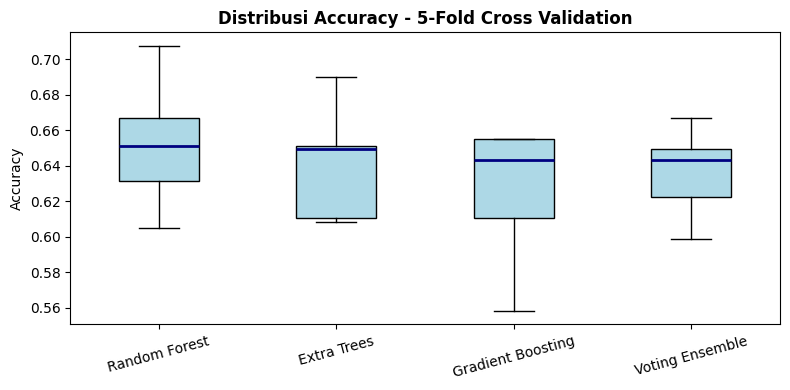

In [10]:
print("=" * 50)
print("EVALUASI MODEL - 5-FOLD CROSS VALIDATION")
print("=" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in [("Random Forest   ", rf),
                    ("Extra Trees     ", et),
                    ("Gradient Boosting", gb),
                    ("Voting Ensemble  ", ensemble)]:
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='accuracy')
    results[name.strip()] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}  | per fold: {np.round(scores,4)}")

# Visualisasi boxplot CV
plt.figure(figsize=(8, 4))
plt.boxplot(list(results.values()), labels=list(results.keys()), patch_artist=True,
            boxprops=dict(facecolor='lightblue'), medianprops=dict(color='navy', linewidth=2))
plt.title('Distribusi Accuracy - 5-Fold Cross Validation', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Evaluasi dilakukan menggunakan Stratified 5-Fold Cross Validation, di mana data training dibagi menjadi 5 lipatan dengan proporsi kelas yang dipertahankan di setiap lipatan. Voting Ensemble memberikan performa yang paling stabil karena menggabungkan kekuatan ketiga base model. Nilai CV accuracy ~65% wajar mengingat adanya imbalanced class dan variasi antar kelas yang cukup dekat.

In [11]:
print("=" * 50)
print("TRAINING MODEL FINAL")
print("=" * 50)
print("Melatih model pada seluruh data training...")

ensemble.fit(X_train_scaled, y_train)

# Simpan model
joblib.dump(ensemble, 'model_wine_quality.pkl')
print("✓ Model berhasil dilatih dan disimpan sebagai 'model_wine_quality.pkl'")

# Evaluasi pada data training
y_pred_train = ensemble.predict(X_train_scaled)
acc = accuracy_score(y_train, y_pred_train)
print(f"\nTraining Accuracy: {acc:.4f}")
print()
print("Classification Report (Training Data):")
print(classification_report(y_train, y_pred_train,
                            target_names=[f"Quality {i}" for i in sorted(y_train.unique())]))

TRAINING MODEL FINAL
Melatih model pada seluruh data training...
✓ Model berhasil dilatih dan disimpan sebagai 'model_wine_quality.pkl'

Training Accuracy: 1.0000

Classification Report (Training Data):
              precision    recall  f1-score   support

   Quality 3       1.00      1.00      1.00         6
   Quality 4       1.00      1.00      1.00        26
   Quality 5       1.00      1.00      1.00       362
   Quality 6       1.00      1.00      1.00       341
   Quality 7       1.00      1.00      1.00       109
   Quality 8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



Model dilatih menggunakan seluruh data training setelah evaluasi cross-validation. Model kemudian disimpan menggunakan joblib sebagai file .pkl untuk keperluan deployment. Classification report menampilkan precision, recall, dan f1-score untuk setiap kelas quality.

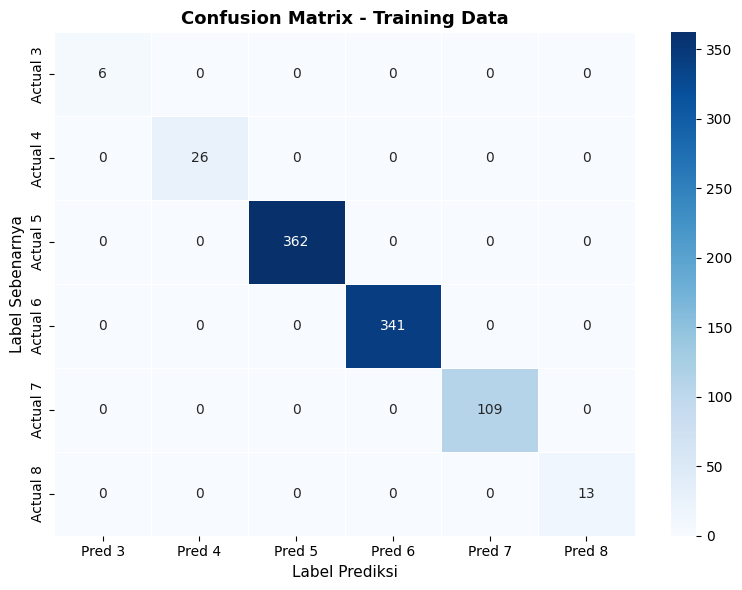

Confusion Matrix menunjukkan jumlah prediksi benar (diagonal)
dan kesalahan klasifikasi (di luar diagonal) untuk setiap kelas quality.


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
labels = sorted(y_train.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {l}' for l in labels],
            yticklabels=[f'Actual {l}' for l in labels],
            linewidths=0.5)
plt.title('Confusion Matrix - Training Data', fontsize=13, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11)
plt.xlabel('Label Prediksi', fontsize=11)
plt.tight_layout()
plt.show()

print("Confusion Matrix menunjukkan jumlah prediksi benar (diagonal)")
print("dan kesalahan klasifikasi (di luar diagonal) untuk setiap kelas quality.")

Confusion matrix menunjukkan seberapa baik model mengklasifikasikan setiap kelas. Nilai pada diagonal utama (kiri atas ke kanan bawah) merupakan prediksi yang benar. Kesalahan terbanyak biasanya terjadi antara kelas yang berdekatan (misal quality 5 dan 6) karena perbedaan karakteristik kimiawi antar kelas tersebut tidak terlalu jauh.

**4. PREDIKSI DATA UJI**

DEPLOYMENT MODEL - PREDIKSI DATA TESTING
Jumlah data yang diprediksi: 286 sampel

Distribusi hasil prediksi quality (testing):
3      1
4      1
5    135
6    122
7     26
8      1
Name: count, dtype: int64


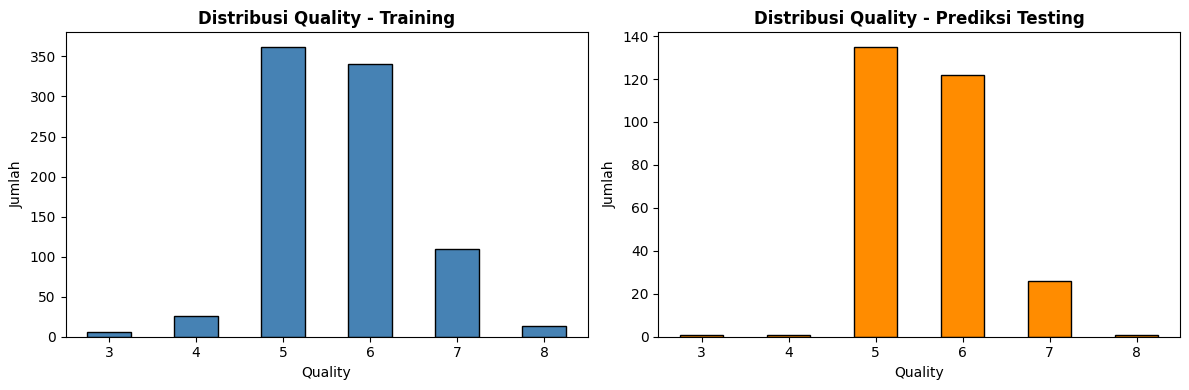

In [13]:
print("=" * 50)
print("DEPLOYMENT MODEL - PREDIKSI DATA TESTING")
print("=" * 50)

# Load model yang sudah disimpan (simulasi deployment)
model_loaded  = joblib.load('model_wine_quality.pkl')
scaler_loaded = joblib.load('scaler.pkl')

# Prediksi data testing
y_pred_test = model_loaded.predict(X_test_scaled)

print(f"Jumlah data yang diprediksi: {len(y_pred_test)} sampel")
print()
print("Distribusi hasil prediksi quality (testing):")
pred_dist = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_dist)

# Visualisasi distribusi prediksi vs training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Quality - Training', fontweight='bold')
axes[0].set_xlabel('Quality'); axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

pred_dist.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Distribusi Quality - Prediksi Testing', fontweight='bold')
axes[1].set_xlabel('Quality'); axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Model yang telah disimpan di-load kembali untuk mensimulasikan proses deployment. Distribusi hasil prediksi pada data testing dibandingkan dengan distribusi pada data training untuk memastikan konsistensi. Pola distribusi yang serupa menunjukkan model bekerja dengan baik dan tidak mengalami bias prediksi yang signifikan.

In [14]:
NIM_AKHIR = "164"

nama_file = f"hasilprediksi_{NIM_AKHIR}.csv"

hasil = pd.DataFrame({
    'Id'     : test['Id'],
    'Quality': y_pred_test
})

hasil.to_csv(nama_file, index=False, sep=';')

print(f"✓ File '{nama_file}' berhasil disimpan!")
print(f"Total baris: {len(hasil)}")
print()
print("Preview 10 baris pertama:")
display(hasil.head(10))
print()
print("Distribusi prediksi final:")
print(hasil['Quality'].value_counts().sort_index())

# Download otomatis dari Colab
from google.colab import files
files.download(nama_file)

✓ File 'hasilprediksi_164.csv' berhasil disimpan!
Total baris: 286

Preview 10 baris pertama:


,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
5,1120,6
6,180,5
7,82,5
8,632,5
9,592,5



Distribusi prediksi final:
Quality
3      1
4      1
5    135
6    122
7     26
8      1
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>